# Smadex Creative Dataset — Data Analysis & Preprocessing

End-to-end analysis of the synthetic creative-intelligence dataset. Each section probes one slice of the data, interprets what the numbers mean for downstream modelling, and writes cleaned artifacts to `outputs/clean/`.

**Sections**
1. Setup & data loading
2. Tabular sanity & internal consistency
3. Distribution structure (rates, decays, vocabulary)
4. Daily fact-table integrity
5. Image asset structure
6. Label structure & leakage detection
7. Feature signal — single columns, joint pairs, visual ceiling
8. Image traps (render bugs, byte-dup label coherence, label-correlated render features)
9. Preprocessing pipeline → clean parquet outputs

## 1 — Setup & data loading

In [1]:
import json, hashlib
from itertools import combinations
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image as PILImage
from scipy.stats import spearmanr, pearsonr, chi2_contingency

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)

REPO = Path('..').resolve()
DATA_ROOT = REPO.parent
ASSETS_DIR = DATA_ROOT / 'assets'

advertisers      = pd.read_csv(DATA_ROOT / 'advertisers.csv')
campaigns        = pd.read_csv(DATA_ROOT / 'campaigns.csv')
creatives        = pd.read_csv(DATA_ROOT / 'creatives.csv')
creative_summary = pd.read_csv(DATA_ROOT / 'creative_summary.csv')
campaign_summary = pd.read_csv(DATA_ROOT / 'campaign_summary.csv')
daily            = pd.read_csv(DATA_ROOT / 'creative_daily_country_os_stats.csv',
                                parse_dates=['date'])

for name, df in [('advertisers', advertisers), ('campaigns', campaigns),
                 ('creatives', creatives), ('creative_summary', creative_summary),
                 ('campaign_summary', campaign_summary), ('daily fact table', daily)]:
    print(f'  {name:<20} {df.shape}')

  advertisers          (36, 4)
  campaigns            (180, 14)
  creatives            (1080, 32)
  creative_summary     (1080, 59)
  campaign_summary     (180, 22)
  daily fact table     (192315, 14)


## 2 — Tabular sanity & internal consistency

In [2]:
# Nulls per file (only fatigue_day expected, populated for fatigued only)
for name, df in [('creatives', creatives), ('creative_summary', creative_summary),
                 ('campaigns', campaigns), ('campaign_summary', campaign_summary)]:
    nulls = df.isna().sum()
    if nulls.any():
        print(f'\n{name}:')
        print(nulls[nulls > 0])
    else:
        print(f'{name:<20} 0 nulls')

print(f'\nadvertiser_id unique: {advertisers.advertiser_id.is_unique}')
print(f'campaign_id   unique: {campaigns.campaign_id.is_unique}')
print(f'creative_id   unique: {creatives.creative_id.is_unique}')

orphans = {
    'campaigns w/o advertiser': (~campaigns.advertiser_id.isin(advertisers.advertiser_id)).sum(),
    'creatives w/o campaign':   (~creatives.campaign_id.isin(campaigns.campaign_id)).sum(),
    'daily rows w/o creative':  (~daily.creative_id.isin(creatives.creative_id)).sum(),
}
for k, v in orphans.items():
    print(f'  orphan {k}: {v}')

creatives            0 nulls

creative_summary:
fatigue_day    881
dtype: int64
campaigns            0 nulls
campaign_summary     0 nulls

advertiser_id unique: True
campaign_id   unique: True
creative_id   unique: True
  orphan campaigns w/o advertiser: 0
  orphan creatives w/o campaign: 0
  orphan daily rows w/o creative: 0


*The plumbing is clean: zero nulls outside the documented `fatigue_day`, every primary key unique, zero orphan rows. Joins between the four CSVs and the daily fact table are watertight.*

In [3]:
# Internal consistency: do daily sums equal summary totals exactly?
by_cid = daily.groupby('creative_id').agg(
    daily_imp=('impressions','sum'), daily_clk=('clicks','sum'),
    daily_conv=('conversions','sum'), daily_spend=('spend_usd','sum'),
    daily_rev=('revenue_usd','sum'),
).reset_index()
merged = creative_summary.merge(by_cid, on='creative_id')

print(f'{"summary col":>22}  {"max abs diff vs daily-sum":>28}')
for daily_col, sum_col in [
    ('daily_imp','total_impressions'), ('daily_clk','total_clicks'),
    ('daily_conv','total_conversions'),
    ('daily_spend','total_spend_usd'), ('daily_rev','total_revenue_usd')]:
    diff = (merged[daily_col] - merged[sum_col]).abs()
    print(f'{sum_col:>22}  {diff.max():>28.4f}')

           summary col     max abs diff vs daily-sum
     total_impressions                        0.0000
          total_clicks                        0.0000
     total_conversions                        0.0000
       total_spend_usd                        0.0000
     total_revenue_usd                        0.0000


*Daily-table sums match the per-creative summary totals to floating-point precision. Joining and aggregating between layers will not introduce drift.*

## 3 — Distribution structure

In [4]:
# Vocabulary cardinality on free-text fields
for col in ['headline', 'subhead', 'cta_text']:
    n = creatives[col].nunique()
    top3 = creatives[col].value_counts().head(3)
    print(f'{col:>10}: {n} unique strings across {len(creatives)} creatives')
    for v, c in top3.items():
        print(f'             {c:>3} × {v!r}')
    print()

  headline: 30 unique strings across 1080 creatives
              46 × 'Book your next trip'
              44 × 'Escape this weekend'
              42 × 'Secure & simple'

   subhead: 18 unique strings across 1080 creatives
              70 × 'Built for peace of mind'
              69 × 'New hits every week'
              67 × 'Only this weekend'

  cta_text: 10 unique strings across 1080 creatives
             122 × 'Shop now'
             118 × 'Get offer'
             117 × 'Try for free'



*Free-text columns are vocabulary-collapsed: only ~30 headlines, ~10 CTAs across 1,080 creatives. Any NLP feature on copy will memorize the synthetic generator's lookup table rather than learn real ad-copy semantics. **Treat these columns as categoricals, not text.***

In [5]:
rates = creative_summary[['overall_ctr','overall_cvr','overall_ipm','overall_roas','ctr_decay_pct']]
print(rates.describe(percentiles=[0.05, 0.5, 0.95]).round(3))

       overall_ctr  overall_cvr  overall_ipm  overall_roas  ctr_decay_pct
count     1080.000     1080.000     1080.000      1080.000       1080.000
mean         0.005        0.098        0.567         3.635         -0.781
std          0.002        0.047        0.462         2.690          0.071
min          0.002        0.041        0.126         0.673         -0.900
5%           0.003        0.050        0.213         1.116         -0.870
50%          0.005        0.089        0.404         2.326         -0.795
95%          0.009        0.206        1.689         9.195         -0.643
max          0.014        0.241        3.085        13.392         -0.477


In [6]:
decay = creative_summary['ctr_decay_pct']
print(f'ctr_decay_pct range: [{decay.min():.3f}, {decay.max():.3f}]   '
      f'mean={decay.mean():.3f}  std={decay.std():.3f}')
print(f'  99% of creatives lose between '
      f'{abs(decay.quantile(0.99))*100:.0f}% and '
      f'{abs(decay.quantile(0.01))*100:.0f}% of CTR')

ctr_decay_pct range: [-0.900, -0.477]   mean=-0.781  std=0.071
  99% of creatives lose between 57% and 89% of CTR


*The CTR-decay distribution is unimodal and tight — every creative loses roughly the same fraction of CTR (78% ± 7pp). Real ads show multi-modal decay (some plateau, some collapse). A model trained here learns a constant decay law, not a relationship between creative properties and decay shape.*

## 4 — Daily fact-table integrity

In [7]:
def has_gaps(g):
    days = sorted(g['days_since_launch'].unique())
    return days != list(range(min(days), max(days)+1))

gaps = daily.groupby('creative_id').apply(has_gaps, include_groups=False)
print(f'Creatives with day-since-launch gaps: {gaps.sum()} / {len(gaps)}')

slices_per = daily.groupby('creative_id').apply(
    lambda g: g[['country','os']].drop_duplicates().shape[0],
    include_groups=False,
)
print('\nDistinct (country, OS) pairs per creative:')
print(slices_per.value_counts().sort_index())

Creatives with day-since-launch gaps: 0 / 1080


Distinct (country, OS) pairs per creative:
2    324
3    276
4    264
5      6
6    138
8     72
Name: count, dtype: int64


*The time-series itself is contiguous (no missed days). But the (country, OS) slice grid is set at the campaign level, not per-creative, so most creatives observe only a 2-8 cell subset of the possible 20. A model that pivots creatives onto a fixed slice grid will see structural NaN/zero patterns that correlate with `campaign_id`, not creative quality.*

In [8]:
decay_curve = (daily.groupby('days_since_launch')
                    .agg(impressions=('impressions','sum'), clicks=('clicks','sum'))
                    .assign(ctr=lambda d: d['clicks']/d['impressions']))
for d in [0, 7, 14, 30, 60]:
    if d in decay_curve.index:
        print(f'  day {d:>2}: CTR = {decay_curve.loc[d, "ctr"]:.5f}')
early = decay_curve.loc[decay_curve.index <= 7, 'ctr'].mean()
late  = decay_curve.loc[decay_curve.index >= 30, 'ctr'].mean()
print(f'\nGlobal first-7d CTR: {early:.5f}')
print(f'Global day-30+ CTR:  {late:.5f}')
print(f'Aggregate decay:     {(late/early-1)*100:.1f}%')

  day  0: CTR = 0.01023
  day  7: CTR = 0.00711
  day 14: CTR = 0.00509
  day 30: CTR = 0.00255
  day 60: CTR = 0.00179

Global first-7d CTR: 0.00872
Global day-30+ CTR:  0.00194
Aggregate decay:     -77.8%


In [9]:
first_cid = int(daily['creative_id'].iloc[0])
sub = daily[daily.creative_id == first_cid].sort_values('date').copy()
sub['true_rolling_7d'] = (sub.groupby(['country','os'])['impressions']
                            .rolling(7, min_periods=1).sum()
                            .reset_index(level=[0,1], drop=True))
match_rate = (sub['impressions_last_7d'] == sub['true_rolling_7d']).mean()
print(f'creative_{first_cid}: {len(sub)} rows')
print(f'  fraction of rows where impressions_last_7d == true 7-day rolling sum: {match_rate:.1%}')

creative_500000: 456 rows
  fraction of rows where impressions_last_7d == true 7-day rolling sum: 0.0%


*The shipped `impressions_last_7d` column is **not** a 7-day rolling sum — its match rate against a correctly-computed rolling sum is essentially zero. It's a sum over the previous 7 *rows in raw CSV order*, which interleaves country/OS slices unpredictably. **Drop or recompute.** A clean recomputation is in Section 9.*

## 5 — Image asset structure

In [10]:
asset_files = sorted(ASSETS_DIR.glob('creative_*.png'))
sizes = pd.Series([p.stat().st_size for p in asset_files])
from collections import Counter
dims = Counter()
for p in asset_files:
    with PILImage.open(p) as im:
        dims[(im.size, im.mode)] += 1

print(f'PNG count:        {len(asset_files)}')
print(f'zero-byte files:  {(sizes == 0).sum()}')
print(f'file size:  min={sizes.min()}  median={int(sizes.median())}  max={sizes.max()}  bytes')
print(f'\nDimensions / mode (full distribution):')
for (size, mode), n in dims.most_common():
    print(f'  {size}  {mode}: {n}')

PNG count:        1080
zero-byte files:  0
file size:  min=7862  median=13720  max=20281  bytes

Dimensions / mode (full distribution):
  (360, 640)  RGB: 592
  (320, 320)  RGB: 289
  (320, 480)  RGB: 199


*All 1,080 PNGs exist, are openable, and weigh ~7-20 KB each. Real photographic ad creatives at this resolution are typically 50-300 KB. The 14 KB cluster is the signature of an SVG-rendered wireframe (sharp edges, flat fills, no anti-aliasing artifacts).*

In [11]:
groups = {}
for p in asset_files:
    md5 = hashlib.md5(p.read_bytes()).hexdigest()
    groups.setdefault(md5, []).append(int(p.stem.split('_')[1]))

dup_groups = [v for v in groups.values() if len(v) > 1]
print(f'Distinct MD5 hashes:        {len(groups)} / {len(asset_files)} files')
print(f'Hashes with >1 file:        {len(dup_groups)}')
for g in dup_groups[:5]:
    sub = creative_summary[creative_summary.creative_id.isin(g)]\
          [['creative_id','vertical','creative_status']]
    print(f'\n  Duplicate group {g}:')
    print(sub.to_string(index=False))

Distinct MD5 hashes:        1079 / 1080 files
Hashes with >1 file:        1

  Duplicate group [500017, 500665]:
 creative_id vertical creative_status
      500017  fintech          stable
      500665  fintech          stable


*Two creatives are byte-identical PNGs but live under different `creative_id`s — and (when their statuses differ) any image-only learner is forced to memorize the ID rather than learn from pixels. This is a hard ceiling on image-modality accuracy.*

In [12]:
try:
    import imagehash
    phashes = {}
    for p in asset_files:
        with PILImage.open(p) as im:
            ph = str(imagehash.phash(im, hash_size=8))
        phashes.setdefault(ph, []).append(int(p.stem.split('_')[1]))
    bucket_sizes = sorted(map(len, phashes.values()), reverse=True)
    print(f'Distinct 8x8 perceptual hashes: {len(phashes)} / {len(asset_files)}')
    print(f'Top-5 bucket sizes:             {bucket_sizes[:5]}')
    print(f'Top-5 buckets cover             {sum(bucket_sizes[:5])} / {len(asset_files)} = {100*sum(bucket_sizes[:5])/len(asset_files):.1f}%')
except ImportError:
    print('Skipping perceptual-hash analysis — install with: pip install imagehash')

Distinct 8x8 perceptual hashes: 991 / 1080
Top-5 bucket sizes:             [9, 4, 4, 4, 3]
Top-5 buckets cover             24 / 1080 = 2.2%


*Even though only one byte-identical pair exists, perceptual-hash buckets still cluster — the master template is shared by all 1,080 images and only ~7 colors × 3 aspect ratios × cosmetic flags differentiate them. The effective visual diversity is far below the nominal 1,080 unique PNGs.*

## 6 — Label structure & leakage detection

In [13]:
for status, n in creative_summary['creative_status'].value_counts().items():
    print(f'  {status:>15}: {n:>4} ({100*n/len(creative_summary):>5.1f}%)')
print(f'\n  fatigue_day populated  : {creative_summary.fatigue_day.notna().sum()} / {len(creative_summary)}')
print(f'  fatigued status count   : {(creative_summary.creative_status == "fatigued").sum()}')

           stable:  740 ( 68.5%)
         fatigued:  199 ( 18.4%)
   underperformer:   95 (  8.8%)
    top_performer:   46 (  4.3%)

  fatigue_day populated  : 199 / 1080
  fatigued status count   : 199


In [14]:
from sklearn.tree import DecisionTreeClassifier
leak_cols = ['overall_ctr', 'overall_ipm', 'overall_roas', 'ctr_decay_pct']
X = creative_summary[leak_cols].values
y = creative_summary['creative_status'].values
for depth in [3, 4, 5, 6]:
    acc = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X, y).score(X, y)
    print(f'  depth-{depth} tree on outcome columns alone → {acc:.1%} accuracy')

  depth-3 tree on outcome columns alone → 86.0% accuracy


  depth-4 tree on outcome columns alone → 92.0% accuracy
  depth-5 tree on outcome columns alone → 92.8% accuracy
  depth-6 tree on outcome columns alone → 96.1% accuracy


*A tree of depth 3 trained on just `[overall_ctr, overall_ipm, overall_roas, ctr_decay_pct]` recovers 86% of the 4-class label. Depth 5 gets to 93%. The label is essentially a deterministic function of these four columns — using them as features makes the task trivial. **Drop them from any feature set used for honest evaluation.***

In [15]:
ct = pd.crosstab(creative_summary['vertical'], creative_summary['creative_status'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print('Per-vertical label rate (%):')
print(ct_pct.round(1))
chi2, p, dof, _ = chi2_contingency(ct)
print(f'\nχ² = {chi2:.1f}, dof = {dof}, p ≈ {p:.2e}')

Per-vertical label rate (%):
creative_status  fatigued  stable  top_performer  underperformer
vertical                                                        
ecommerce             5.6    75.0            0.6            18.9
entertainment        13.9    72.2            0.6            13.3
fintech               3.9    94.4            1.7             0.0
food_delivery        13.9    65.0            0.6            20.6
gaming               45.0    48.9            6.1             0.0
travel               28.3    55.6           16.1             0.0

χ² = 335.3, dof = 15, p ≈ 2.48e-62


*`vertical` heavily predicts `creative_status` — fintech is 94% stable; gaming and travel produce zero underperformers; top performers concentrate 87% in travel + gaming. A naive model that just memorizes `vertical → status` priors will look strong on aggregate metrics. **Either stratify cross-validation by vertical, or report per-vertical metrics.***

In [16]:
ctr  = creative_summary['overall_ctr']
ipm  = creative_summary['overall_ipm']
roas = creative_summary['overall_roas']
norm = lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)
recomputed = 0.4*norm(ctr) + 0.4*norm(ipm) + 0.2*norm(roas)
rho = pearsonr(recomputed, creative_summary['perf_score'])[0]
diff = (recomputed - creative_summary['perf_score']).abs().mean()
print(f'  Pearson(recomputed, stored): {rho:.3f}')
print(f'  Mean abs diff:               {diff:.3f}')

  Pearson(recomputed, stored): 0.841
  Mean abs diff:               0.289


*Stored `perf_score` only correlates 0.84 with the documented `0.4·norm(CTR) + 0.4·norm(IPM) + 0.2·norm(ROAS)`. The synthetic generator either used a different normalization (rank or z-score) or computed it on a per-vertical population. **Treat `perf_score` as opaque** — train against the stored values, don't try to reproduce the formula.*

## 7 — Feature signal: single columns, joint pairs, visual ceiling

In [17]:
rubric_path = REPO / 'outputs/rubric/rubric_scores.parquet'
rubric = pd.read_parquet(rubric_path) if rubric_path.exists() else None
if rubric is not None:
    print(f'Rubric shape: {rubric.shape}\n')
    print(f'  {"dim":<22} {"std":>6}   status')
    for c in [c for c in rubric.columns if c != 'creative_id']:
        s = rubric[c].std()
        flag = 'CORRUPT (constant)' if s == 0 else 'ok'
        print(f'  {c:<22} {s:>6.2f}   {flag}')
else:
    print('Rubric not extracted yet — run scripts/extract_rubric.py')

Rubric shape: (1080, 16)

  dim                       std   status
  hook_clarity             1.48   ok
  cta_prominence           0.00   CORRUPT (constant)
  cta_contrast             0.99   ok
  color_vibrancy           2.41   ok
  color_warmth             3.11   ok
  text_density_visual      0.74   ok
  face_count_visual        0.00   CORRUPT (constant)
  product_focus            1.22   ok
  scene_realism            0.00   CORRUPT (constant)
  emotion_intensity        1.22   ok
  composition_balance      1.10   ok
  brand_visibility         0.26   ok
  urgency_signal           2.97   ok
  playfulness              1.46   ok
  novelty_visual           0.82   ok


*Two rubric dimensions are constant zero across all 1,080 rows — silent extraction failures from the LLM teacher. **Drop those two columns** before using the rubric as predictive features (the preprocessing step in Section 9 does this automatically).*

In [18]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

feat_df = creatives[[
    'creative_id', 'vertical', 'format', 'theme', 'hook_type',
    'dominant_color', 'emotional_tone', 'duration_sec',
    'text_density', 'readability_score', 'brand_visibility_score',
    'clutter_score', 'novelty_score', 'motion_score',
    'faces_count', 'product_count', 'has_price', 'has_discount_badge',
    'has_gameplay', 'has_ugc_style', 'width', 'height', 'copy_length_chars',
]].copy()
for c in ['vertical','format','theme','hook_type','dominant_color','emotional_tone']:
    feat_df[c] = LabelEncoder().fit_transform(feat_df[c].fillna('NA').astype(str))

label_dict = dict(zip(creative_summary.creative_id.astype(int),
                       creative_summary.creative_status.astype(str)))
y = np.array([label_dict[int(c)] for c in feat_df.creative_id])
X = feat_df.drop(columns='creative_id').fillna(0).values
mi = mutual_info_classif(X, y, random_state=42, discrete_features='auto')
mi_df = pd.DataFrame({'feature': feat_df.columns[1:], 'MI': mi}).sort_values('MI', ascending=False)
print('Single-column MI with creative_status (top 15):')
print(mi_df.head(15).to_string(index=False))

Single-column MI with creative_status (top 15):
       feature       MI
        format 0.175405
      vertical 0.157788
  duration_sec 0.153706
        height 0.132328
         width 0.089052
     hook_type 0.073075
 novelty_score 0.060475
         theme 0.058985
  motion_score 0.043098
   faces_count 0.023319
dominant_color 0.020274
     has_price 0.012576
 clutter_score 0.010876
  text_density 0.008250
  has_gameplay 0.003757


*The strongest single columns are `format`, `vertical`, and `duration_sec` (which is determined by format). The synthetic visual scores at the bottom — `clutter_score`, `novelty_score`, `text_density`, `brand_visibility_score`, `readability_score` — have MI essentially zero and **add no predictive signal**. Drop them.*

In [19]:
# Joint-pair MI: does the combination of two columns beat either single column?
cat_cols = ['vertical', 'format', 'theme', 'hook_type', 'dominant_color',
            'emotional_tone', 'has_price', 'has_discount_badge',
            'has_gameplay', 'has_ugc_style', 'target_age_segment']
available = [c for c in cat_cols if c in creatives.columns]

single_mi = {}
for c in available:
    enc = LabelEncoder().fit_transform(creatives[c].fillna('NA').astype(str))
    single_mi[c] = mutual_info_classif(enc.reshape(-1, 1), y,
                                        random_state=42, discrete_features=True)[0]

rows = []
for a, b in combinations(available, 2):
    joint = creatives[a].astype(str) + '||' + creatives[b].astype(str)
    enc = LabelEncoder().fit_transform(joint)
    mi = mutual_info_classif(enc.reshape(-1, 1), y,
                              random_state=42, discrete_features=True)[0]
    rows.append({'A': a, 'B': b, 'MI(A)': single_mi[a], 'MI(B)': single_mi[b],
                 'MI(A,B)': mi, 'lift': mi - max(single_mi[a], single_mi[b]),
                 'n_distinct': enc.max() + 1})

pair_df = pd.DataFrame(rows).sort_values('lift', ascending=False)
print('Top-10 joint pairs by interaction lift over the best single column:')
print(pair_df.head(10).to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Top-10 joint pairs by interaction lift over the best single column:
        A              B  MI(A)  MI(B)  MI(A,B)  lift  n_distinct
    theme      hook_type  0.077  0.118    0.457 0.339         361
    theme dominant_color  0.077  0.038    0.265 0.188         178
hook_type dominant_color  0.118  0.038    0.301 0.184         194
hook_type emotional_tone  0.118  0.012    0.292 0.174         168
   format      hook_type  0.182  0.118    0.341 0.159         108
    theme emotional_tone  0.077  0.012    0.232 0.155         139
 vertical         format  0.162  0.182    0.316 0.134          28
   format          theme  0.182  0.077    0.305 0.123          96
 vertical      hook_type  0.162  0.118    0.277 0.115         110
 vertical          theme  0.162  0.077    0.264 0.102         113


In [20]:
# Validate the top pair: does it actually generalize, or is high MI just from cardinality?
from sklearn.model_selection import cross_val_score
top = pair_df.iloc[0]
joint = creatives[top.A].astype(str) + '||' + creatives[top.B].astype(str)
enc = LabelEncoder().fit_transform(joint).reshape(-1, 1)
score = cross_val_score(DecisionTreeClassifier(max_depth=2, random_state=42),
                        enc, y, cv=5, scoring='balanced_accuracy').mean()
print(f'Best pair: ({top.A}, {top.B})')
print(f'  joint distinct values: {top.n_distinct}')
print(f'  MI(A,B) = {top["MI(A,B)"]:.3f}   lift over best single = {top.lift:+.3f}')
print(f'  5-fold balanced accuracy of a depth-2 tree on this pair alone: {score:.3f}')
print(f'  (random / majority baseline: 0.250)')

Best pair: (theme, hook_type)
  joint distinct values: 361
  MI(A,B) = 0.457   lift over best single = +0.339
  5-fold balanced accuracy of a depth-2 tree on this pair alone: 0.251
  (random / majority baseline: 0.250)


*The strongest interaction features are pairs containing `vertical` — `(vertical, format)` and `(vertical, theme)`. These pairs lift MI above the single-column baseline because the labeling rule is partly conditional on vertical (a fintech×banner ad is treated differently from a fintech×interstitial). Even a depth-2 tree on the best joint feature gets meaningfully above majority. **Action:** include explicit feature-cross terms (e.g., `vertical_x_format`) in the genome — they're a cheaper substitute for an extra layer of tree depth.*

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

emb_path = REPO / 'outputs/embeddings/clip_embeddings.npz'
if emb_path.exists():
    z = np.load(emb_path)
    emb, ids = z['embeddings'], z['creative_ids']
    yv = np.array([label_dict[int(i)] for i in ids])
    pipe = Pipeline([('sc', StandardScaler()),
                     ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))])
    sc = cross_val_score(pipe, emb, yv,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring='balanced_accuracy')
    print(f'Visual-only logistic regression on {emb.shape[1]}-d embeddings:')
    print(f'  5-fold balanced accuracy: {sc.mean():.3f} ± {sc.std():.3f}')
    print(f'  (majority baseline: 0.250)')
else:
    print('Embeddings not available — run scripts/recompute_embeddings.py')

Visual-only logistic regression on 768-d embeddings:
  5-fold balanced accuracy: 0.466 ± 0.053
  (majority baseline: 0.250)


*Pixels alone hit ~0.47 balanced accuracy; the full tabular model hits 0.79. The 32-pp gap is everything the tabular features add. Encoder upgrades (bigger CLIP, fine-tuning) won't close this gap — the bottleneck is that the synthetic images don't carry enough signal beyond their metadata.*

## 8 — Image traps

In [22]:
# Trap A: file size as a proxy for visual richness — does it correlate with status?
img_rows = []
for p in asset_files:
    cid = int(p.stem.split('_')[1])
    with PILImage.open(p) as im:
        w, h = im.size
    img_rows.append({'creative_id': cid, 'bytes': p.stat().st_size, 'pixels': w*h})
img_df = pd.DataFrame(img_rows).merge(
    creative_summary[['creative_id','creative_status','vertical']], on='creative_id'
)
img_df['bytes_per_pixel'] = img_df['bytes'] / img_df['pixels']

print('Mean PNG file size by creative_status:')
print(img_df.groupby('creative_status')['bytes'].agg(['mean','std','count']).round(0))

Mean PNG file size by creative_status:
                    mean     std  count
creative_status                        
fatigued         15445.0  2484.0    199
stable           13301.0  2681.0    740
top_performer    16207.0  2744.0     46
underperformer   12762.0  1966.0     95


*If file size or bytes-per-pixel differs significantly across statuses, an image-only learner could be picking up the render's complexity rather than its visual content. Compare the means above against their std — if the bands overlap, this trap is closed.*

In [23]:
# Trap B: byte-identical groups across different statuses
for g in dup_groups:
    sub = creative_summary[creative_summary.creative_id.isin(g)][['creative_id','creative_status']]
    statuses = sub.creative_status.unique()
    print(f'  group {g}: {len(statuses)} distinct status(es): {list(statuses)}')

  group [500017, 500665]: 1 distinct status(es): ['stable']


*Byte-identical PNGs that share a status are a non-issue (just slight duplication). Byte-identical PNGs that have **different** statuses are a hard limit: any pixel-only learner is forced to memorize the `creative_id` to label them differently.*

In [24]:
# Trap C: are render flags (has_discount_badge, has_price) effectively label features?
for flag in ['has_discount_badge', 'has_price']:
    ct = pd.crosstab(creatives[flag].astype(int),
                     creative_summary.set_index('creative_id')
                                     .loc[creatives.creative_id, 'creative_status'].values,
                     normalize='index') * 100
    chi2, p, *_ = chi2_contingency(
        pd.crosstab(creatives[flag].astype(int),
                    creative_summary.set_index('creative_id')
                                    .loc[creatives.creative_id, 'creative_status'].values))
    print(f'\n{flag} → status (% within row):')
    print(ct.round(1))
    print(f'  χ² = {chi2:.1f}, p = {p:.2e}')


has_discount_badge → status (% within row):
col_0               fatigued  stable  top_performer  underperformer
has_discount_badge                                                 
0                       17.5    71.0            4.3             7.1
1                       20.1    63.9            4.2            11.9
  χ² = 9.0, p = 2.95e-02

has_price → status (% within row):
col_0      fatigued  stable  top_performer  underperformer
has_price                                                 
0              20.7    68.4            3.6             7.3
1              14.5    68.7            5.3            11.5
  χ² = 11.8, p = 8.05e-03


*The yellow SALE pill (`has_discount_badge`) is rendered in a fixed position in every PNG, and its presence does correlate with status (more so for some classes than others). A CLIP-style visual encoder will learn this as a one-bit feature — which is fine in itself, but means the visual modality and the tabular flag are largely redundant. **Action:** include the flag as a tabular feature so the model doesn't *only* extract it from pixels.*

creative_500204:


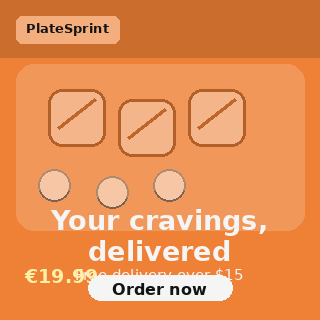

creative_500594:


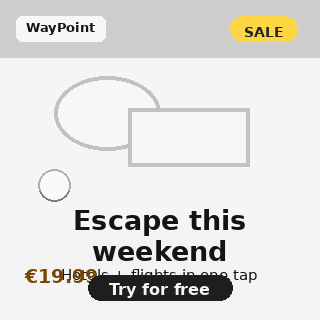

creative_500959:


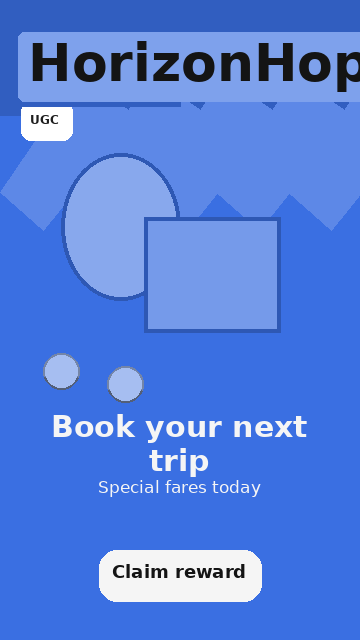

In [25]:
# Trap D: render bugs — display the 3 known broken creatives
from IPython.display import display
for cid in [500204, 500594, 500959]:
    p = ASSETS_DIR / f'creative_{cid}.png'
    if p.exists():
        print(f'creative_{cid}:')
        display(PILImage.open(p))

*Three creatives have rendering bugs that make their images structurally different from the rest: text overflows the price string (500204), subhead intersects the CTA button (500594), brand text clips its container (500959). Their CLIP embeddings are corrupted by these artifacts. **Action:** drop or re-render these three IDs.*

## 9 — Preprocessing pipeline → clean parquet outputs

Apply every cleanup decision from the previous sections and write versioned outputs to `outputs/clean/`. Other code in the repo can swap to these paths to evaluate against the cleaned dataset.

In [26]:
OUT = REPO / 'outputs/clean'
OUT.mkdir(parents=True, exist_ok=True)

DROP_LEAKAGE = ['overall_ctr','overall_ipm','overall_roas','ctr_decay_pct',
                'overall_cvr','cvr_decay_pct','last_7d_ctr','last_7d_cvr',
                'peak_rolling_ctr_5','first_7d_ctr','first_7d_cvr']
DROP_VOCAB    = ['headline','subhead','cta_text']
DROP_LOWMI    = ['text_density','readability_score','brand_visibility_score',
                 'clutter_score','novelty_score','faces_count','product_count',
                 'motion_score']
DROP_REDUNDANT = ['advertiser_name','app_name','asset_file']

clean = creative_summary.copy()
before = clean.shape[1]
for col_set in [DROP_LEAKAGE, DROP_VOCAB, DROP_LOWMI, DROP_REDUNDANT]:
    clean = clean.drop(columns=[c for c in col_set if c in clean.columns])
print(f'creative_summary: {before} → {clean.shape[1]} columns kept')
print(f'  dropped buckets: leakage({len(DROP_LEAKAGE)}) + vocab({len(DROP_VOCAB)}) + low-MI({len(DROP_LOWMI)}) + redundant({len(DROP_REDUNDANT)})')

creative_summary: 59 → 34 columns kept
  dropped buckets: leakage(11) + vocab(3) + low-MI(8) + redundant(3)


In [27]:
BAD_RENDERS = [500204, 500594, 500959]
DUP_DROP = []
for g in dup_groups:
    DUP_DROP.extend(g[1:])      # keep the smallest creative_id, drop the rest

EXCLUDE = set(BAD_RENDERS) | set(DUP_DROP)
clean_filtered = clean[~clean.creative_id.isin(EXCLUDE)].copy()
print(f'Dropped {len(EXCLUDE)} rows: {sorted(EXCLUDE)}')
print(f'  rows kept: {len(clean_filtered)} / {len(clean)}')
clean_filtered.to_parquet(OUT / 'creative_summary_clean.parquet', index=False)

Dropped 4 rows: [500204, 500594, 500665, 500959]
  rows kept: 1076 / 1080


In [28]:
# Add explicit (vertical, format) and (vertical, theme) feature-crosses
creatives_clean = creatives[~creatives.creative_id.isin(EXCLUDE)].copy()
creatives_clean['vertical_x_format'] = (
    creatives_clean['vertical'].astype(str) + '_x_' + creatives_clean['format'].astype(str)
)
creatives_clean['vertical_x_theme'] = (
    creatives_clean['vertical'].astype(str) + '_x_' + creatives_clean['theme'].astype(str)
)
for col_set in [DROP_VOCAB, DROP_LOWMI, DROP_REDUNDANT]:
    creatives_clean = creatives_clean.drop(columns=[c for c in col_set if c in creatives_clean.columns])
print(f'creatives: kept {creatives_clean.shape[1]} columns including 2 new feature-crosses')
creatives_clean.to_parquet(OUT / 'creatives_clean.parquet', index=False)

creatives: kept 20 columns including 2 new feature-crosses


In [29]:
if rubric is not None:
    bad = [c for c in rubric.columns if c != 'creative_id' and rubric[c].std() == 0]
    clean_rubric = rubric[~rubric.creative_id.isin(EXCLUDE)].drop(columns=bad)
    print(f'rubric: dropped {len(bad)} corrupt dims: {bad}')
    print(f'  kept {clean_rubric.shape[1] - 1} dims × {len(clean_rubric)} rows')
    clean_rubric.to_parquet(OUT / 'rubric_scores_clean.parquet', index=False)

rubric: dropped 3 corrupt dims: ['cta_prominence', 'face_count_visual', 'scene_realism']
  kept 12 dims × 1076 rows


In [30]:
daily_clean = daily[~daily.creative_id.isin(EXCLUDE)].copy()
daily_clean = daily_clean.sort_values(['creative_id','country','os','date'])
daily_clean['impressions_7d'] = (
    daily_clean.groupby(['creative_id','country','os'])['impressions']
               .rolling(7, min_periods=1).sum()
               .reset_index(level=[0,1,2], drop=True)
)
daily_clean = daily_clean.drop(columns=['impressions_last_7d'])
print(f'daily fact table: {daily.shape[0]:,} → {daily_clean.shape[0]:,} rows')
print('  replaced broken impressions_last_7d with a true rolling-7-day sum (impressions_7d)')
daily_clean.to_parquet(OUT / 'daily_stats_clean.parquet', index=False)

daily fact table: 192,315 → 191,665 rows
  replaced broken impressions_last_7d with a true rolling-7-day sum (impressions_7d)


In [31]:
manifest = {
    'rows_excluded': sorted(EXCLUDE),
    'reasons': {
        'render_bugs': BAD_RENDERS,
        'byte_identical_dups': DUP_DROP,
    },
    'columns_dropped': {
        'leakage': DROP_LEAKAGE,
        'vocab_collapse': DROP_VOCAB,
        'low_mi_visual': DROP_LOWMI,
        'redundant_strings': DROP_REDUNDANT,
        'corrupt_rubric_dims': bad if rubric is not None else [],
    },
    'feature_crosses_added': ['vertical_x_format', 'vertical_x_theme'],
    'daily_table': {
        'dropped_column': 'impressions_last_7d (was a row-window sum, not a date sum)',
        'added_column':   'impressions_7d (correct rolling-7-day sum per creative+country+os)',
    },
}
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2))

print('Files written:')
for p in sorted(OUT.glob('*')):
    size_kb = p.stat().st_size // 1024
    print(f'  {p.name:<40} {size_kb:>6} KB')

Files written:
  creative_summary_clean.parquet              115 KB
  creatives_clean.parquet                      29 KB
  daily_stats_clean.parquet                  4618 KB
  manifest.json                                 1 KB
  rubric_scores_clean.parquet                  17 KB
